# V1.7 — Skeleton precipitation under load

**Targets:** Decision #22; ARCHITECTURE §III.7 ("the morphogenetic scaffold"). Protocol §V1.7.

**Claim.** Stress-driven deposition — *Wolff's law as a generative rule* (the same rule the tree
uses for reaction wood) — under a creature's load case yields a **connected, load-bearing**
skeleton, and changing the load (low gravity; a radiance *support law-domain*) changes the
skeleton accordingly. If the cheap local feedback rule instead produced disconnected /
non-load-bearing junk, the architecture's "origin of structure" mechanism would fail and
skeletons would have to be authored → **REDESIGN** (use topology optimization directly as the
precipitation operator).

**Mechanism under test** (`wolff.py`): Huiskes/Mullender homeostatic bone remodeling in its
fully-stressed form — seed full, sense the spatially-filtered strain-energy stimulus `S`,
remodel `ρ ← ρ·(S/k)^η` toward a homeostatic setpoint `k`. (The multiplicative update is the
load-bearing fix: the stimulus is steeply density-dependent, `S∝ρ⁻⁴` for a loaded strut, so a
linear update is a stiff feedback that oscillates and *fragments*; the FSD update is matched to
that exponent and converges.)

**Independent oracle** (`topology_opt.py`): standard **SIMP** compliance minimization (OC update
+ sensitivity filter) — a mature, trusted global optimizer. Wolff is judged against it.

**Fairness.** Both paths use the *same* 3D FE boundary-value solver. Compliance is compared as
**continuous compliance at matched continuous volume** (SIMP optimized at `volfrac = mean(ρ_w)`,
both scored with the same penalized stiffness ⇒ ratio ≥ 1). Connectivity is a *separate* check
on the `ρ>0.5` solid set: the load-bearing skeleton is the largest 26-connected component, which
must hold ≥95% of the material and reach the supports.

**Note.** This is the first Tier-1 verification that is *throughput-bound* and genuinely uses the
GPU (3D FE via cupy-CG), unlike CPU-bound V1.1–V1.6.

| # | Criterion | Pre-registered threshold (frozen) |
|---|---|---|
| A,B | **connectivity** | largest 26-connected component holds ≥ **0.95** of solid AND reaches supports — both the cantilever and the creature Earth-g skeleton |
| A,B | **compliance** | continuous `C_wolff / C_simp ≤ 2.0` at matched volume — both domains |
| C | **morphology monotone** | creature solid-fraction strictly **decreases** as gravity decreases |
| C | **seraph near-nothing** | radiance support-field (α=1) settles solid-fraction ≤ **0.02** |
| D | **determinism** | repeat run compliance rel. diff < **1e-6** (CG tolerance regime, V0.5) |


In [1]:
"""(1) Setup — imports, frozen pre-registered constants, the Wolff-vs-SIMP helper."""
import sys, pathlib, time
import numpy as np
import matplotlib.pyplot as plt

REPO = pathlib.Path.cwd()
while not (REPO / "src" / "verification" / "oracles" / "wolff.py").exists():
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "src" / "verification" / "oracles"))
RESULTS = REPO / "verification_notebooks" / "phase1" / "results"

import topology_opt as to
import wolff as wf

np.set_printoptions(precision=4, suppress=True)

# ---- frozen constants (calibrated in _calib_v17.py, frozen with margin BEFORE this runs) ----
FE          = to.FEParams()                       # E0=1, Emin=1e-9, nu=0.3, penal=3, rmin=1.5
DIMS_CANT   = (32, 12, 6);  K_CANT  = 0.08        # cantilever calibration domain + setpoint
DIMS_CREAT  = (24, 8, 20);  K_CREAT = 400.0       # creature (biped torso) domain + setpoint
GRAV        = [1.0, 0.4, 0.15]                    # gravity sweep (Earth -> low)
SIMP_ITER   = 60
RATIO_MAX   = 2.0                                 # compliance criterion
CONN_FRAC   = 0.95                                # connectivity criterion (largest component)
SERAPH_MAX  = 0.02                                # seraph "near-nothing" criterion
DET_TOL     = 1e-6                                # determinism criterion

def wolff_vs_simp(dims, domain, supp, k, simp_iter=SIMP_ITER):
    """Run Wolff to a fixed point and SIMP at the matched continuous volume; compare."""
    res = wf.run_wolff(dims, domain, wp=wf.WolffParams(k=k), fp=FE)
    Vc  = float(res["rho"].mean())
    c_w = to.compliance_of(dims, res["rho"], domain, FE)
    rho_s, hist = to.simp_optimize(dims, domain, volfrac=Vc, params=FE, n_iter=simp_iter)
    c_s = to.compliance_of(dims, rho_s, domain, FE)
    con = to.connectivity((res["rho"] > 0.5).astype(float), supp, frac_threshold=CONN_FRAC)
    return dict(res=res, rho_s=rho_s, Vc=Vc, c_w=c_w, c_s=c_s, ratio=c_w / c_s, con=con,
                simp_hist=hist)

print("backend:", "GPU (cupy CG)" if to._HAS_GPU else "CPU (sparse LU)")


backend: GPU (cupy CG)


## (A) Cantilever — oracle calibration

The textbook topology-optimization benchmark (one face clamped, a downward tip load). It
calibrates that the comparison machinery is sound on a case with a known answer: Wolff should
precipitate a connected load-path whose compliance is within 2× of the SIMP optimum at matched
volume.

In [2]:
"""(2) A: cantilever — connectivity + compliance vs SIMP."""
dom_cant, supp_cant = to.build_cantilever(DIMS_CANT, load=1.0)
t = time.time()
A = wolff_vs_simp(DIMS_CANT, dom_cant, supp_cant, K_CANT)
print("cantilever:  Vcont=%.3f  C_wolff=%.4e  C_simp=%.4e  ratio=%.3f  (%.1fs, %d Wolff its)"
      % (A["Vc"], A["c_w"], A["c_s"], A["ratio"], time.time() - t, A["res"]["n_iter"]))
print("  connectivity:", A["con"])
A_conn  = A["con"]["connected"]
A_ratio = A["ratio"] <= RATIO_MAX
print("  [A] connected=%s (frac=%.3f >= %.2f)   ratio_ok=%s (%.3f <= %.1f)"
      % (A_conn, A["con"]["frac_in_largest"], CONN_FRAC, A_ratio, A["ratio"], RATIO_MAX))


cantilever:  Vcont=0.624  C_wolff=7.5880e+01  C_simp=6.4723e+01  ratio=1.172  (16.7s, 71 Wolff its)
  connectivity: {'n_components': 1, 'frac_in_largest': 1.0, 'touches_support': True, 'connected': True}
  [A] connected=True (frac=1.000 >= 0.95)   ratio_ok=True (1.172 <= 2.0)


## (B) Creature, Earth gravity — the Decision-#22 skeleton

A 2-foot torso under self-weight (gravity body load, fixed nominal tissue mass). The skeleton
must **precipitate** from the full block: a connected, load-bearing structure channeling the
distributed weight to the feet, competitive with the SIMP optimum.

In [3]:
"""(3) B: creature Earth-g — connectivity + compliance vs SIMP."""
dom_e, supp_c = to.build_creature(DIMS_CREAT, g=1.0)
t = time.time()
B = wolff_vs_simp(DIMS_CREAT, dom_e, supp_c, K_CREAT)
print("creature@g=1: Vcont=%.3f  solid=%.3f  C_wolff=%.4e  C_simp=%.4e  ratio=%.3f  (%.1fs, %d its)"
      % (B["Vc"], B["res"]["solid_frac"], B["c_w"], B["c_s"], B["ratio"],
         time.time() - t, B["res"]["n_iter"]))
print("  connectivity:", B["con"])
B_conn  = B["con"]["connected"]
B_ratio = B["ratio"] <= RATIO_MAX
print("  [B] connected=%s (frac=%.3f >= %.2f)   ratio_ok=%s (%.3f <= %.1f)"
      % (B_conn, B["con"]["frac_in_largest"], CONN_FRAC, B_ratio, B["ratio"], RATIO_MAX))


creature@g=1: Vcont=0.744  solid=0.855  C_wolff=1.3563e+06  C_simp=1.3180e+06  ratio=1.029  (8.7s, 28 its)
  connectivity: {'n_components': 1, 'frac_in_largest': 1.0, 'touches_support': True, 'connected': True}
  [B] connected=True (frac=1.000 >= 0.95)   ratio_ok=True (1.029 <= 2.0)


## (C) Morphology sensitivity & the seraph support-field

Holding the setpoint `k` fixed, the skeleton must respond to the **load**: lower gravity recruits
less material (monotone), and a radiance **support law-domain** (the seraph, α=1) that cancels
gravity must precipitate **near-nothing** — the metaphysical-knob coherence check (Decision #26).
(At very low load the sparse precipitate naturally thins toward and then to nothing — exactly the
architecture's prediction.)

In [4]:
"""(4) C: gravity sweep (monotone) + seraph (near-nothing)."""
sweep = []
for g in GRAV:
    if g == 1.0:
        r = B["res"]                          # reuse the Earth-g run from (B)
    else:
        dom_g, _ = to.build_creature(DIMS_CREAT, g=g)
        r = wf.run_wolff(DIMS_CREAT, dom_g, wp=wf.WolffParams(k=K_CREAT), fp=FE)
    sweep.append((g, r["solid_frac"]))
    print("  g=%.2f  solid_fraction=%.3f  converged=%s" % (g, r["solid_frac"], r["converged"]))

dom_s, _ = to.build_creature(DIMS_CREAT, g=1.0, support_alpha=1.0)
res_seraph = wf.run_wolff(DIMS_CREAT, dom_s, wp=wf.WolffParams(k=K_CREAT), fp=FE)
seraph_frac = res_seraph["solid_frac"]
print("  seraph (alpha=1): solid_fraction=%.4f" % seraph_frac)

fracs = [f for _, f in sweep]
C_monotone = all(fracs[i] > fracs[i + 1] for i in range(len(fracs) - 1))
C_seraph   = seraph_frac <= SERAPH_MAX
print("  [C] monotone(decreasing with g)=%s %s   seraph_near_nothing=%s (%.4f <= %.2f)"
      % (C_monotone, [round(f, 3) for f in fracs], C_seraph, seraph_frac, SERAPH_MAX))


  g=1.00  solid_fraction=0.855  converged=True


  g=0.40  solid_fraction=0.624  converged=False


  g=0.15  solid_fraction=0.208  converged=True


  seraph (alpha=1): solid_fraction=0.0000
  [C] monotone(decreasing with g)=True [0.855, 0.624, 0.208]   seraph_near_nothing=True (0.0000 <= 0.02)


## (D) Determinism guard

The whole stack must be reproducible (Decision #3 / V0.5). A repeat of the creature Earth-g run
must match to the CG tolerance regime.

In [5]:
"""(5) D: determinism — repeat the creature Earth-g Wolff run."""
res_rep = wf.run_wolff(DIMS_CREAT, dom_e, wp=wf.WolffParams(k=K_CREAT), fp=FE)
det_rel = abs(B["res"]["compliance"] - res_rep["compliance"]) / abs(B["res"]["compliance"])
D_det = det_rel < DET_TOL
print("  [D] determinism rel diff = %.2e  (< %.0e) -> %s" % (det_rel, DET_TOL, D_det))


  [D] determinism rel diff = 0.00e+00  (< 1e-06) -> True


## Figure

saved /workspace/nebula/verification_notebooks/phase1/results/V1_7_skeleton_precipitation.png


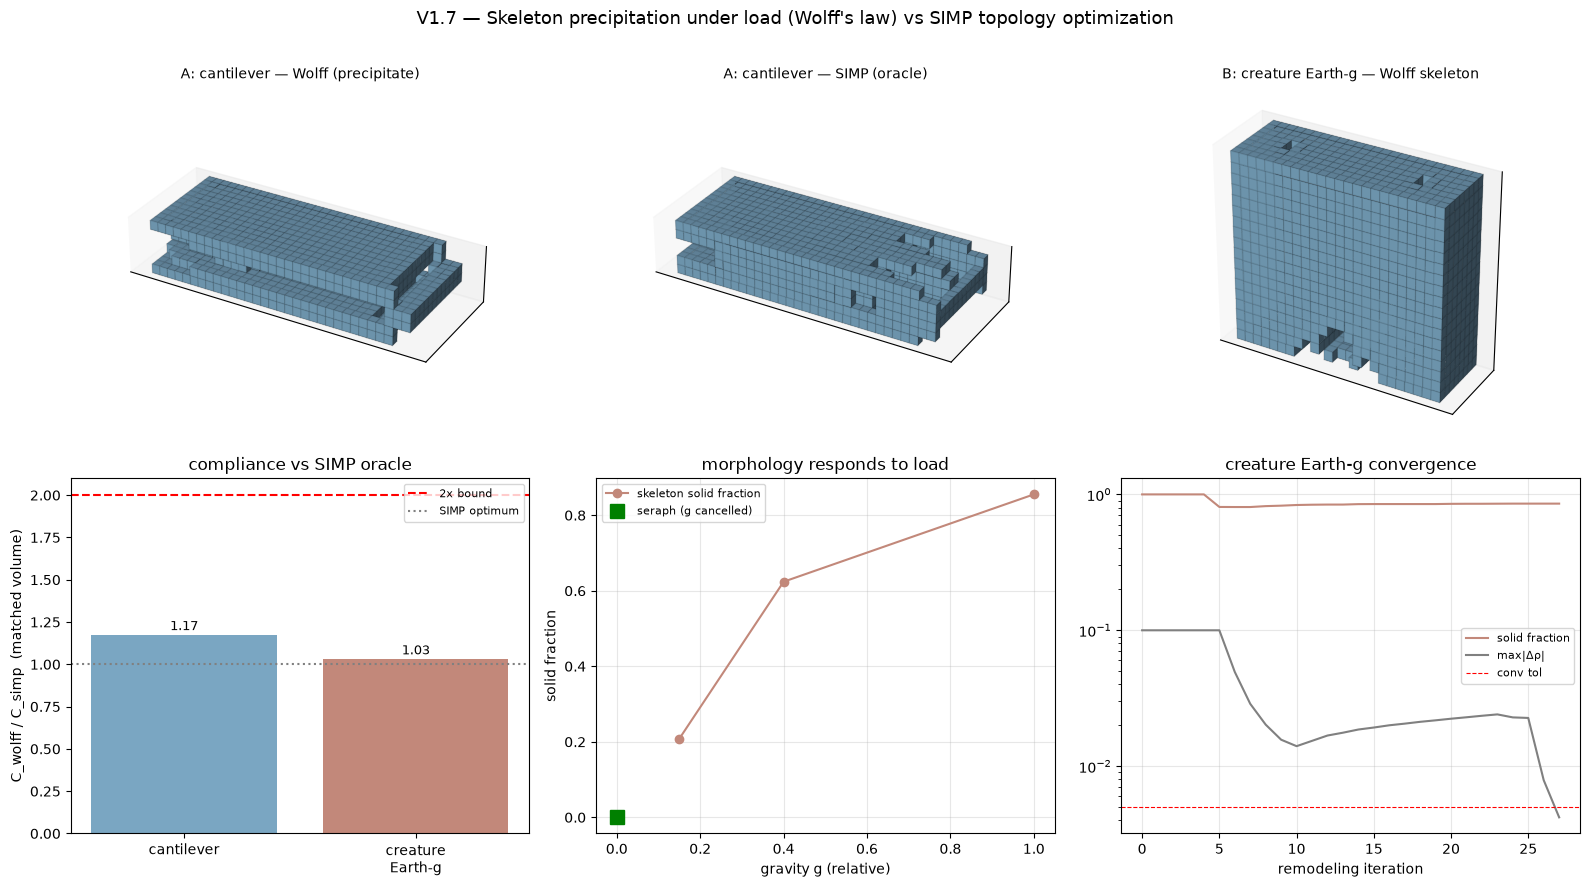

In [6]:
"""(6) Figure: SIMP vs Wolff structures, compliance ratios, morphology, convergence."""
fig = plt.figure(figsize=(16, 9))

def voxel_panel(pos, rho, title):
    ax = fig.add_subplot(pos, projection="3d")
    sol = rho > 0.5
    ax.voxels(sol, facecolors="#7aa6c2", edgecolor=(0, 0, 0, 0.08))
    ax.set_title(title, fontsize=10)
    ax.set_box_aspect(sol.shape)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])

voxel_panel(231, A["res"]["rho"], "A: cantilever — Wolff (precipitate)")
voxel_panel(232, to.binarize(A["rho_s"], A["Vc"]), "A: cantilever — SIMP (oracle)")
voxel_panel(233, B["res"]["rho"], "B: creature Earth-g — Wolff skeleton")

# compliance ratio bars
ax = fig.add_subplot(234)
labels = ["cantilever", "creature\nEarth-g"]
ratios = [A["ratio"], B["ratio"]]
bars = ax.bar(labels, ratios, color=["#7aa6c2", "#c2887a"])
ax.axhline(RATIO_MAX, color="red", ls="--", label="2x bound")
ax.axhline(1.0, color="gray", ls=":", label="SIMP optimum")
ax.set_ylabel("C_wolff / C_simp  (matched volume)")
ax.set_title("compliance vs SIMP oracle"); ax.legend(fontsize=8)
for b, r in zip(bars, ratios):
    ax.text(b.get_x() + b.get_width() / 2, r + 0.03, "%.2f" % r, ha="center", fontsize=9)

# morphology: solid fraction vs gravity (+ seraph)
ax = fig.add_subplot(235)
gg = [g for g, _ in sweep]
ax.plot(gg, fracs, "o-", color="#c2887a", label="skeleton solid fraction")
ax.plot([0.0], [seraph_frac], "s", color="green", ms=10, label="seraph (g cancelled)")
ax.set_xlabel("gravity g (relative)"); ax.set_ylabel("solid fraction")
ax.set_title("morphology responds to load"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# convergence history
ax = fig.add_subplot(236)
ax.plot(B["res"]["hist_vol"], color="#c2887a", label="solid fraction")
ax.plot(B["res"]["hist_dr"], color="gray", label="max|Δρ|")
ax.axhline(wf.WolffParams().dtol, color="red", ls="--", lw=0.8, label="conv tol")
ax.set_xlabel("remodeling iteration"); ax.set_title("creature Earth-g convergence")
ax.set_yscale("log"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig.suptitle("V1.7 — Skeleton precipitation under load (Wolff's law) vs SIMP topology optimization",
             fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(RESULTS / "V1_7_skeleton_precipitation.png", dpi=110, bbox_inches="tight")
print("saved", RESULTS / "V1_7_skeleton_precipitation.png")
plt.show()


In [7]:
"""(7) Frozen verdict."""
def verdict(name, passed, detail):
    print("  [%s] %-34s %s" % ("OK" if passed else "XX", name, detail))

print("=" * 84)
print("V1.7 VERDICT — skeleton precipitation under load (Wolff's law) vs SIMP")
print("=" * 84)
verdict("A connectivity (cantilever)", A_conn,
        "frac=%.3f >= %.2f, reaches support" % (A["con"]["frac_in_largest"], CONN_FRAC))
verdict("A compliance  (cantilever)", A_ratio, "ratio=%.3f <= %.1f" % (A["ratio"], RATIO_MAX))
verdict("B connectivity (creature)",  B_conn,
        "frac=%.3f >= %.2f, reaches support" % (B["con"]["frac_in_largest"], CONN_FRAC))
verdict("B compliance  (creature)",   B_ratio, "ratio=%.3f <= %.1f" % (B["ratio"], RATIO_MAX))
verdict("C morphology monotone",      C_monotone, "solid frac vs g: %s" % [round(f, 3) for f in fracs])
verdict("C seraph near-nothing",      C_seraph, "seraph solid=%.4f <= %.2f" % (seraph_frac, SERAPH_MAX))
verdict("D determinism",              D_det, "rel diff=%.2e < %.0e" % (det_rel, DET_TOL))

ALL_PASS = all([A_conn, A_ratio, B_conn, B_ratio, C_monotone, C_seraph, D_det])
print("-" * 84)
if ALL_PASS:
    print("  V1.7 OVERALL: PASS")
    print("  -> Wolff's-law deposition self-organizes a connected, load-bearing skeleton")
    print("     competitive with the SIMP optimum; it responds correctly to gravity and to a")
    print("     radiance support law-domain. Decision #22 (skeleton = precipitate) holds.")
    print("     (Standing note: the fully-stressed multiplicative update is required for stability;")
    print("      a naive linear SED rule oscillates and fragments. This is the deposition operator.)")
else:
    print("  V1.7 OVERALL: FAIL - see outcome class above (failure class: REDESIGN).")
print("=" * 84)
assert ALL_PASS, "V1.7 did not pass - see verdict above."


V1.7 VERDICT — skeleton precipitation under load (Wolff's law) vs SIMP
  [OK] A connectivity (cantilever)        frac=1.000 >= 0.95, reaches support
  [OK] A compliance  (cantilever)         ratio=1.172 <= 2.0
  [OK] B connectivity (creature)          frac=1.000 >= 0.95, reaches support
  [OK] B compliance  (creature)           ratio=1.029 <= 2.0
  [OK] C morphology monotone              solid frac vs g: [0.855, 0.624, 0.208]
  [OK] C seraph near-nothing              seraph solid=0.0000 <= 0.02
  [OK] D determinism                      rel diff=0.00e+00 < 1e-06
------------------------------------------------------------------------------------
  V1.7 OVERALL: PASS
  -> Wolff's-law deposition self-organizes a connected, load-bearing skeleton
     competitive with the SIMP optimum; it responds correctly to gravity and to a
     radiance support law-domain. Decision #22 (skeleton = precipitate) holds.
     (Standing note: the fully-stressed multiplicative update is required for stability